# BESS Peak-Shaving Load Forecasting Case Study

**Decision objective.** Forecast a German C&I site's 15-minute demand well enough to protect demand-charge peaks while preserving battery capacity for arbitrage. This case emphasizes data quality, temporal validation, interpretable baselines, and asymmetric operational risk.

**Executive finding.** The data is a 2025 15-minute series. Valid zero-load periods are structured shutdowns; 24 readings are missing or physically implausible and are flagged, with only isolated gaps interpolated. The weekly seasonal-naive benchmark has approximately 16 kW MAE in the final 56-day holdout. A conservative 80th-percentile residual uplift reduces peak under-forecasting from roughly 88% to 72%, while increasing average error.

**Recommended operating posture.** Use the weekly seasonal forecast as a transparent benchmark, add a calibrated conservative reserve when missed peaks are more costly than excess battery reservation, and refresh the forecast every 15 minutes over a 1-4 hour control horizon. Treat holidays and abnormal process days as separate operating regimes once production data is available.

This notebook is deliberately compact and delegates reusable logic to `src/bess_forecasting.py`; `main.py` is the runnable entry point.

## How to read this notebook

The notebook is presentation-oriented: reusable analysis lives in `src/bess_forecasting.py`, and the code cells below are short calls that display the results.

### 1. Setup and data quality
The setup call parses the German-locale CSV, creates the regular 15-minute grid, flags sensor artifacts, preserves valid zero-load shutdowns, and reports the remaining missing intervals.

### 2. Peak-shaving EDA
The EDA figures show annual variability, weekday/weekend behavior, peak timing, and the weekday/time-of-day combinations where the battery should reserve capacity. The representative EDA week is selected by distance to the median complete-week profile, not by forecast performance.

### 3. Forecast models and validation
The forecast section compares a weekly seasonal-naive benchmark with a conservative q80 uplift. Model fitting and residual calibration use only pre-holdout observations. The final 56-day holdout is kept intact for scoring, while the forecast illustration uses the first complete Monday-Sunday holdout week selected by calendar and data availability.

For each horizon, forecasts are generated from a rolling origin: the one-week historical source is available at the origin, and the future target is scored only after the requested 15-minute, 1-hour, or 4-hour lead time. This prevents random splits and target leakage.

### 4. Calendar and dispatch
German public holidays are added as an available explanatory flag. The dispatch example tracks battery state of charge, power limits, energy discharged, and a simple illustrative opportunity-cost estimate; it is not a tariff settlement calculation.

The saved figures are in `outputs/plots/`, and the full pipeline remains runnable with `python main.py`.

## Model research and selection logic

The available data supports a disciplined model ladder rather than an immediate jump to deep learning. Keep persistence, daily-naive, weekly-naive, conservative-naive, and OLS as governance baselines. The current ridge challenger adds short lags, daily/weekly lags, shifted rolling means, time-of-day, weekday, and holiday flags while controlling correlated features with regularization.

The strongest realistic next accuracy candidate is a shallow gradient-boosted tree model with absolute-error or quantile loss. It can learn nonlinear interactions between schedule and recent load, but must be evaluated on earlier rolling folds and held out once at the end. Quantile boosting is especially relevant because it can estimate a high conditional load quantile directly rather than applying one global uplift.

SARIMAX is reasonable when stable autocorrelation and reliable exogenous variables are available, but seasonal order selection at 15-minute frequency is heavier and easier to overfit. LSTM/Transformer models are not justified by one site-year of data; they become more credible with multiple years or multiple sites.

See `model_research.md` for the full advantages/drawbacks matrix, selection criteria, and client information that would change the recommendation.

In [52]:
# Setup: initialize the reusable case pipeline and inspect data quality.
from pathlib import Path
import sys
import importlib
import numpy as np
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = Path("c:/Users/DieVT/Downloads/Claude Machine Learning Projects/2026_BESS_PeakShavings")
sys.path.insert(0, str(ROOT))
import src.bess_forecasting as bess
bess = importlib.reload(bess)
np.random.seed(42)
DATA, OUTPUT, PLOT_DIR, frame, raw = bess.initialize_case(ROOT)
print(f"Python {sys.version.split()[0]} | {len(frame):,} regular 15-minute rows")
print(f"Date range: {frame.index.min():%d %b %Y} to {frame.index.max():%d %b %Y}")
print(f"Observed gaps: {(~frame.was_observed).sum()} | artifacts: {frame.is_artifact.sum()} | unresolved missing: {frame.load_kw.isna().sum()}")

Python 3.9.5 | 35,040 regular 15-minute rows
Date range: 01 Jan 2025 to 31 Dec 2025
Observed gaps: 157 | artifacts: 163 | unresolved missing: 141


### Data loading and preparation
The setup call parses the German-locale CSV, creates the regular 15-minute grid, flags sensor artifacts, preserves valid zero-load shutdowns, and reports the remaining missing intervals.

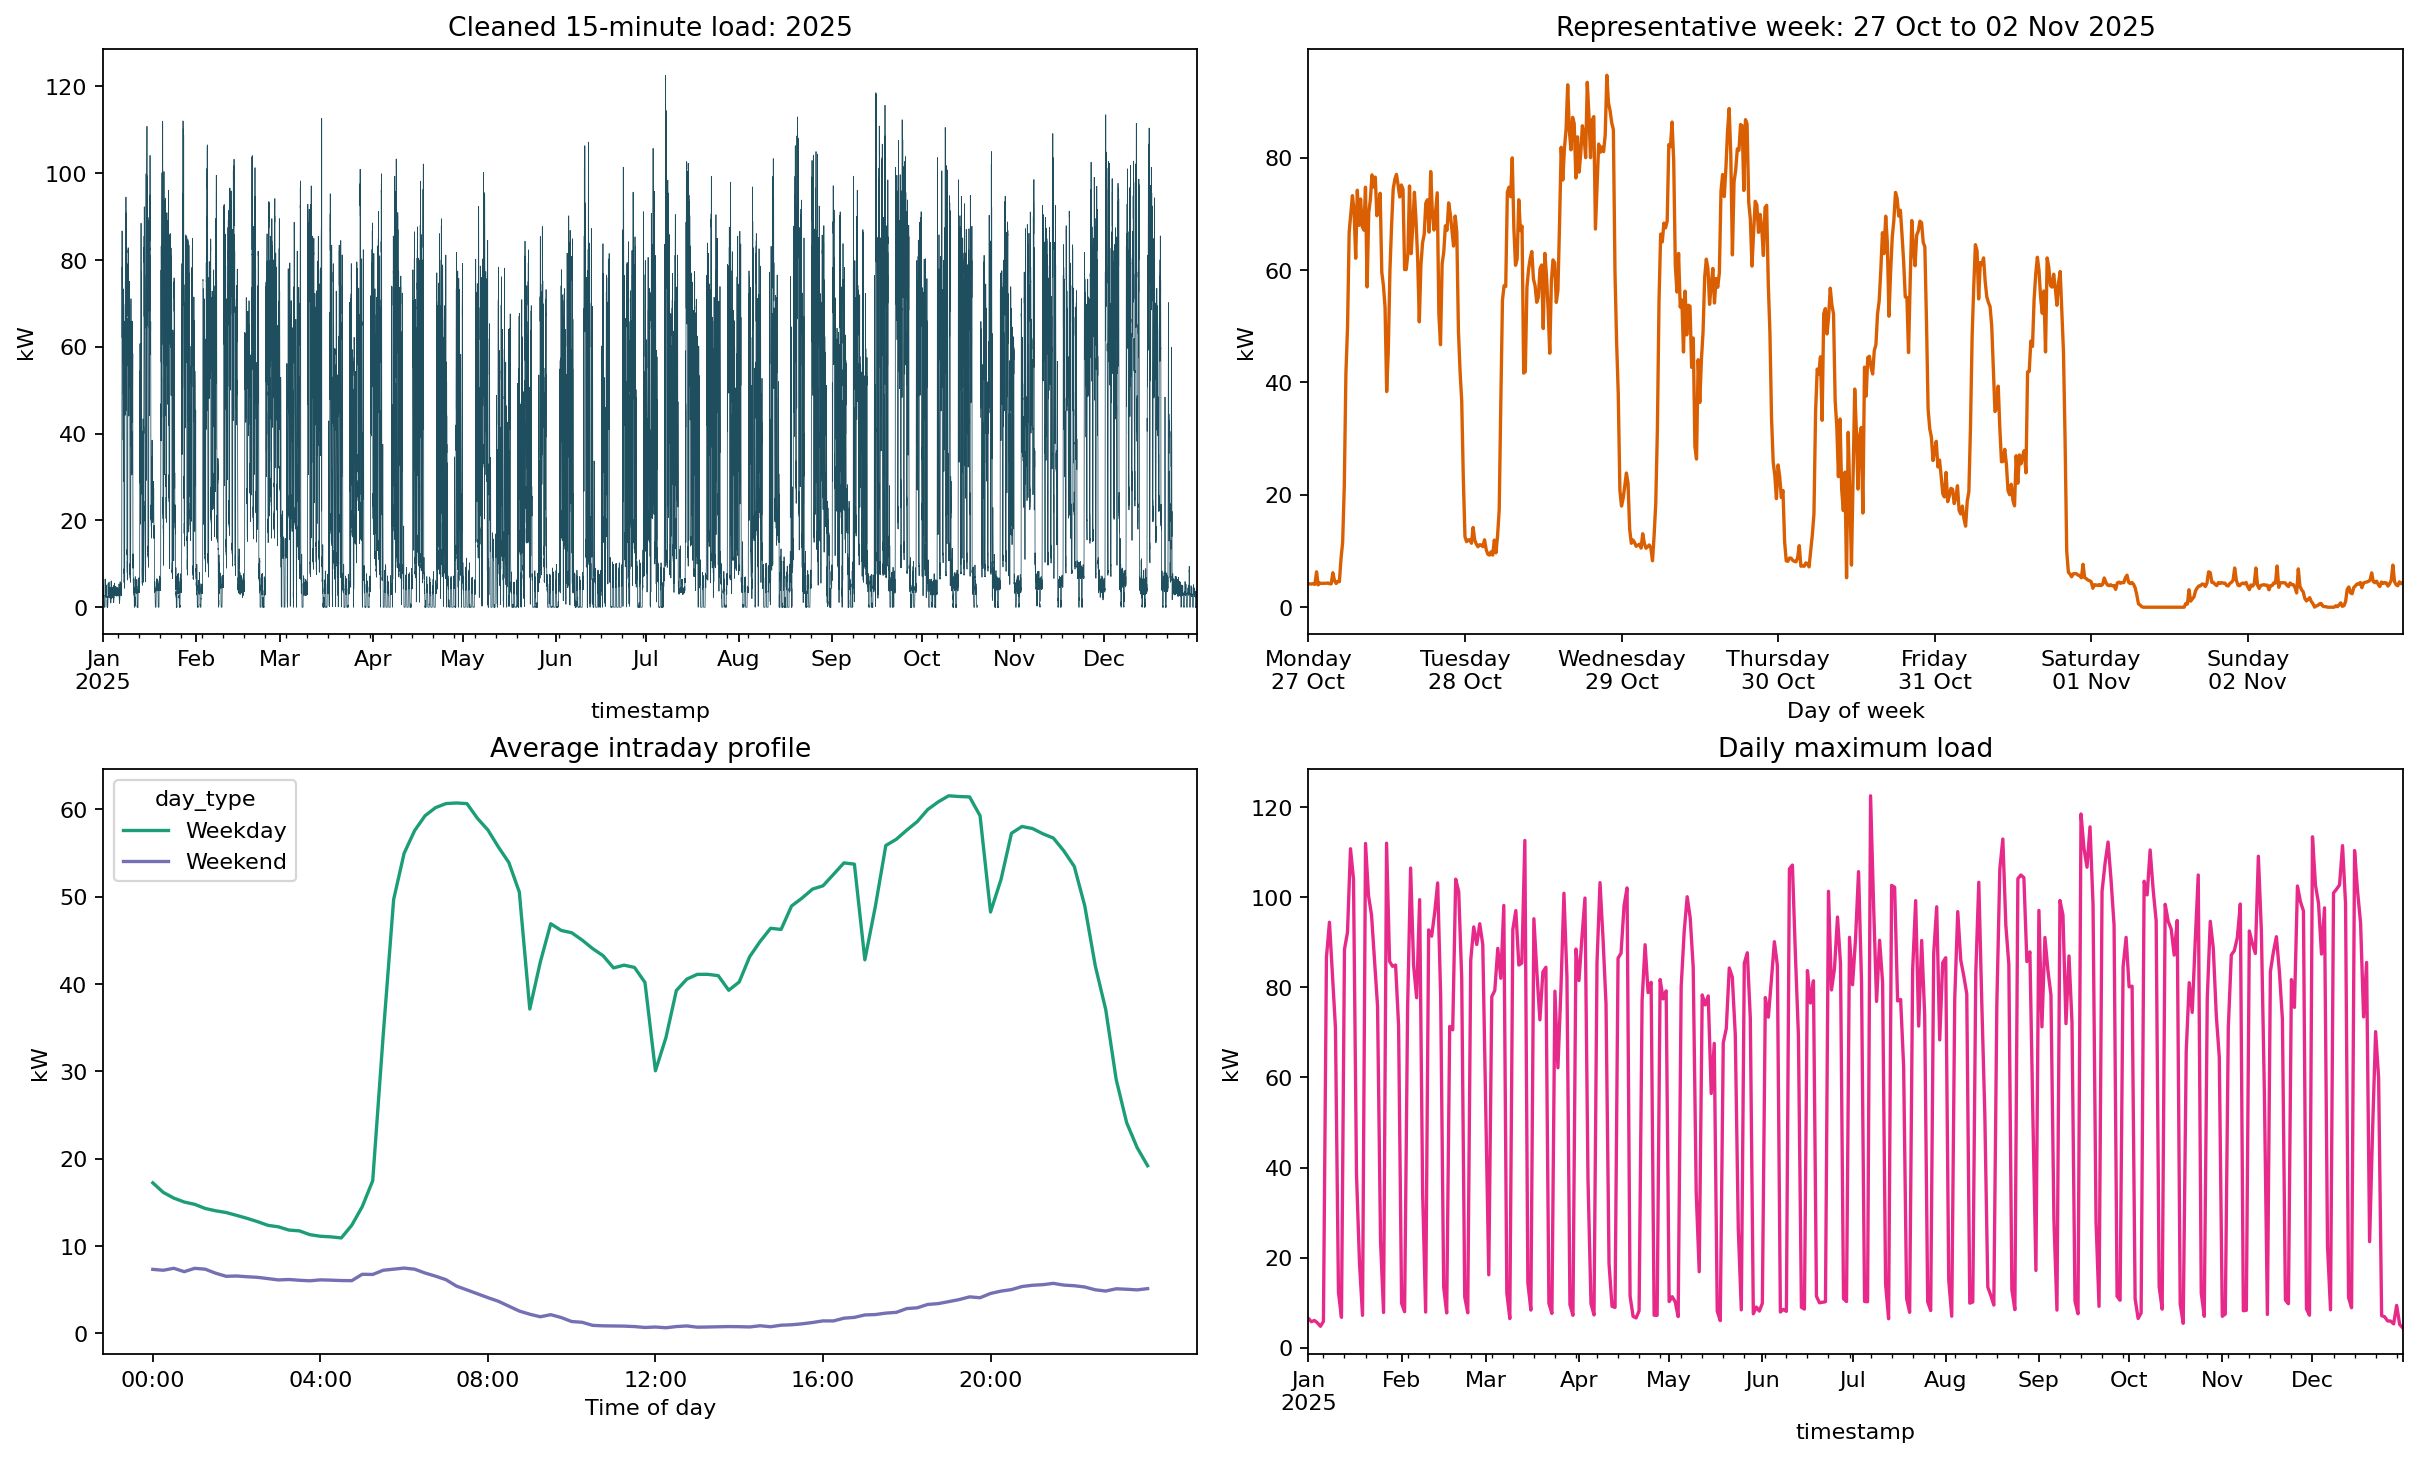

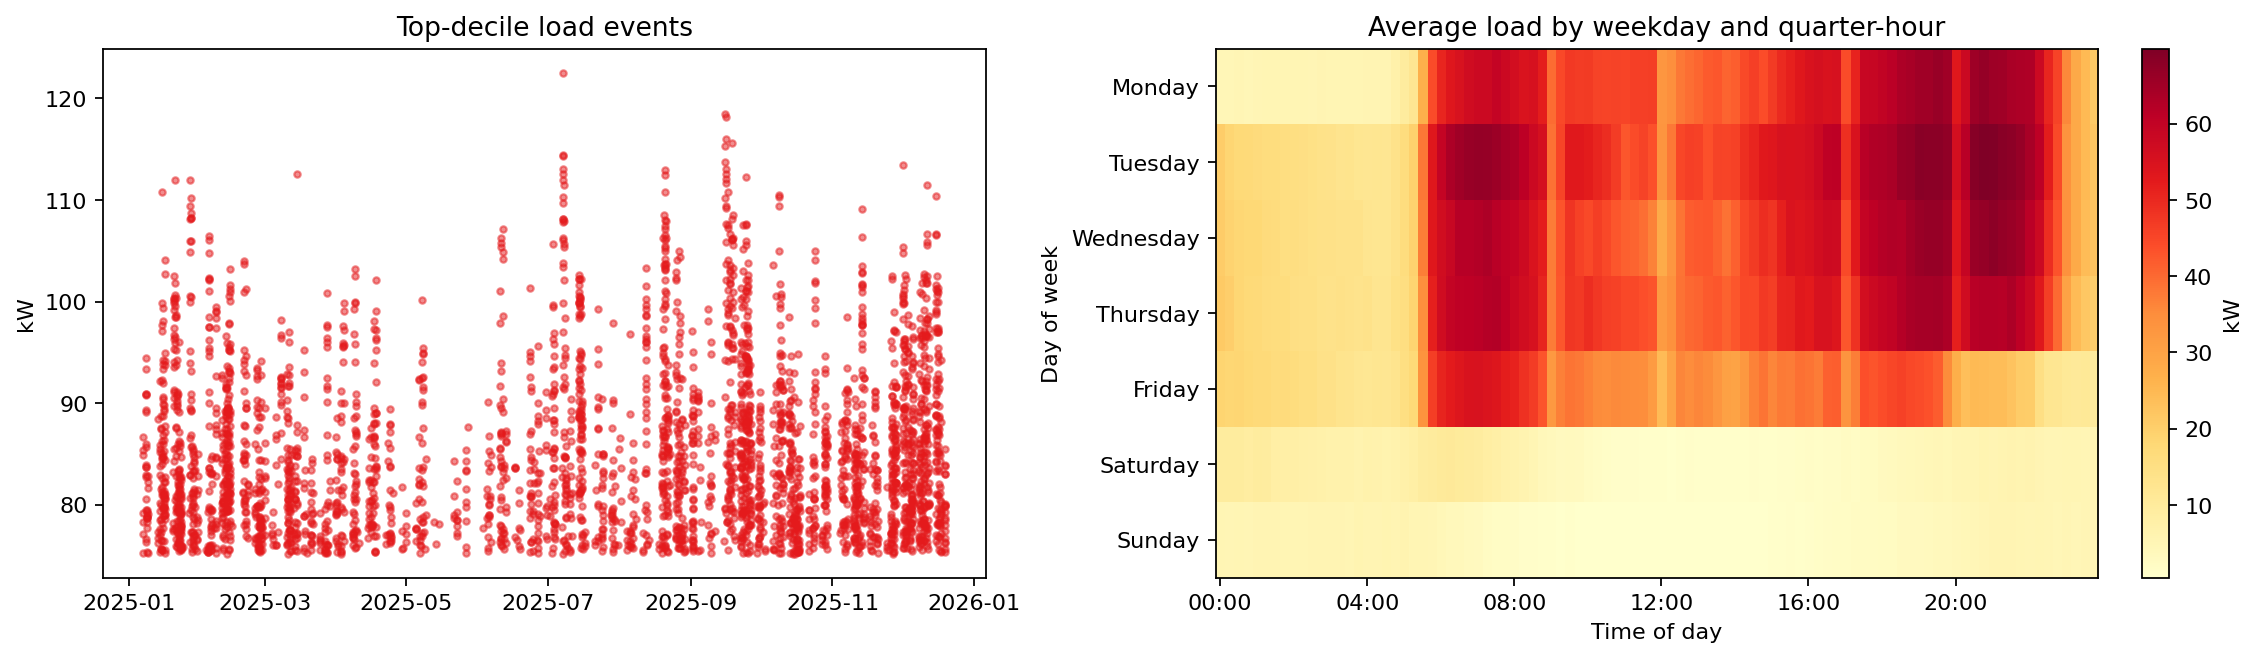

In [46]:
eda_paths = bess.plot_eda(frame, PLOT_DIR); display(*[Image(filename=str(path)) for path in eda_paths])

### What the EDA shows
The first figure summarizes the site's operating shape and weekday/weekend contrast. The second identifies when high-load events occur and therefore when discharge capacity is commercially valuable. The printed persistence statistics indicate how long a peak may need to be covered.

Ridge challenger metrics: {'n': 5266.0, 'mae_kw': 3.7765389640093283, 'rmse_kw': 5.968091564722136, 'underforecast_rate': 0.443790353209267, 'underforecast_mae_kw': 4.1243700469639135, 'peak_underforecast_rate': 0.7438330170777988, 'peak_underforecast_mae_kw': 8.092621481299705, 'weighted_absolute_error_kw': 5.606894603917165, 'peak_cutoff_kw': 80.35}


,fold,model,n,mae_kw,rmse_kw,underforecast_rate,underforecast_mae_kw,peak_underforecast_rate,peak_underforecast_mae_kw,weighted_absolute_error_kw,peak_cutoff_kw
0,1,weekly_seasonal_naive,2688.0,17.061946,27.582582,0.326265,10.926203,0.776952,20.645742,20.626782,79.618
1,1,conservative_q80,2688.0,25.300428,34.150452,0.105655,13.478592,0.516729,15.462302,26.724505,79.618
2,1,ridge_load_calendar,2688.0,3.372794,5.291569,0.405134,3.561546,0.695167,7.723509,4.815697,79.618
3,2,weekly_seasonal_naive,2672.0,14.928291,21.578250,0.576347,15.420130,0.970149,32.663231,23.815641,81.512
4,2,conservative_q80,2672.0,18.387408,23.258145,0.263847,17.536312,0.869403,23.743433,23.014316,81.512
5,2,ridge_load_calendar,2578.0,4.196866,6.596528,0.483708,4.599598,0.799228,8.259684,6.421729,81.720
6,3,weekly_seasonal_naive,2497.0,13.152739,20.788411,0.493793,14.365717,0.876000,30.380457,20.246423,77.236
7,3,conservative_q80,2497.0,18.237305,23.471019,0.199039,18.317867,0.684000,25.211579,21.883272,77.236
8,3,ridge_load_calendar,2402.0,4.144168,6.703723,0.452956,4.584891,0.790123,7.285799,6.220921,77.520


,horizon_15min,model,n,mae_kw,rmse_kw,underforecast_rate,underforecast_mae_kw,peak_underforecast_rate,peak_underforecast_mae_kw,weighted_absolute_error_kw,peak_cutoff_kw
0,1,weekly_seasonal_naive,5359.0,15.999795,24.774039,0.450830,13.791921,0.884328,27.391350,22.217612,80.248
1,1,conservative_q80,5359.0,21.645688,29.028791,0.187162,16.300140,0.718284,20.392208,24.696451,80.248
2,4,weekly_seasonal_naive,5356.0,16.003955,24.780094,0.450523,13.798409,0.884328,27.391350,22.220452,80.260
3,4,conservative_q80,5356.0,21.655904,29.036764,0.187267,16.300140,0.718284,20.392208,24.708376,80.260
4,16,weekly_seasonal_naive,5344.0,16.002605,24.795278,0.449289,13.784382,0.885981,27.391350,22.195775,80.322
5,16,conservative_q80,5344.0,21.694147,29.068401,0.185442,16.441514,0.719626,20.392208,24.743088,80.322


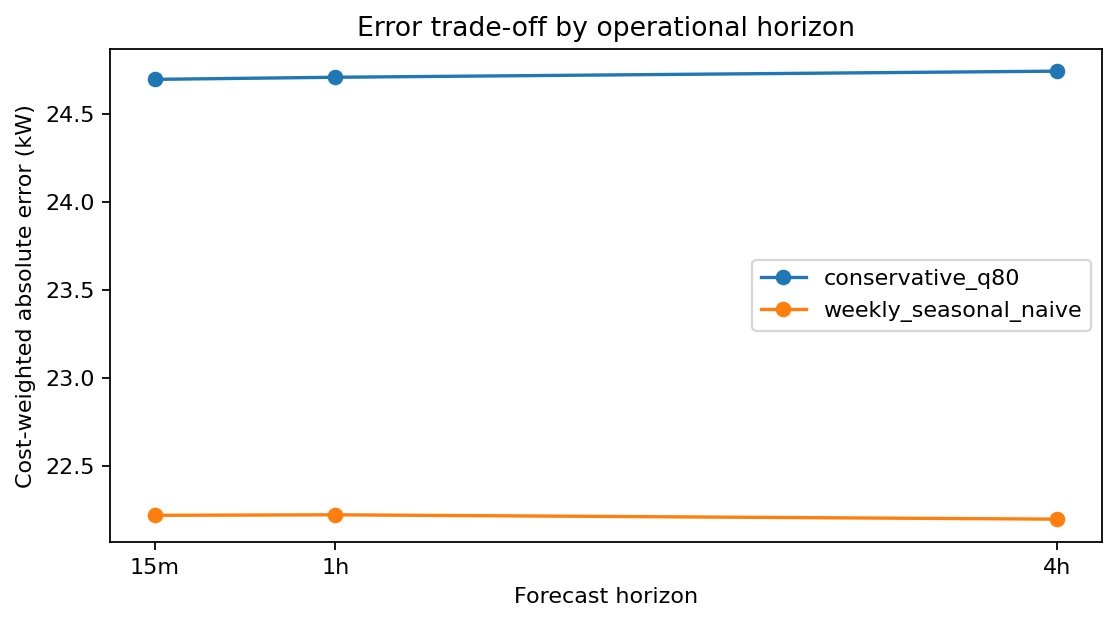

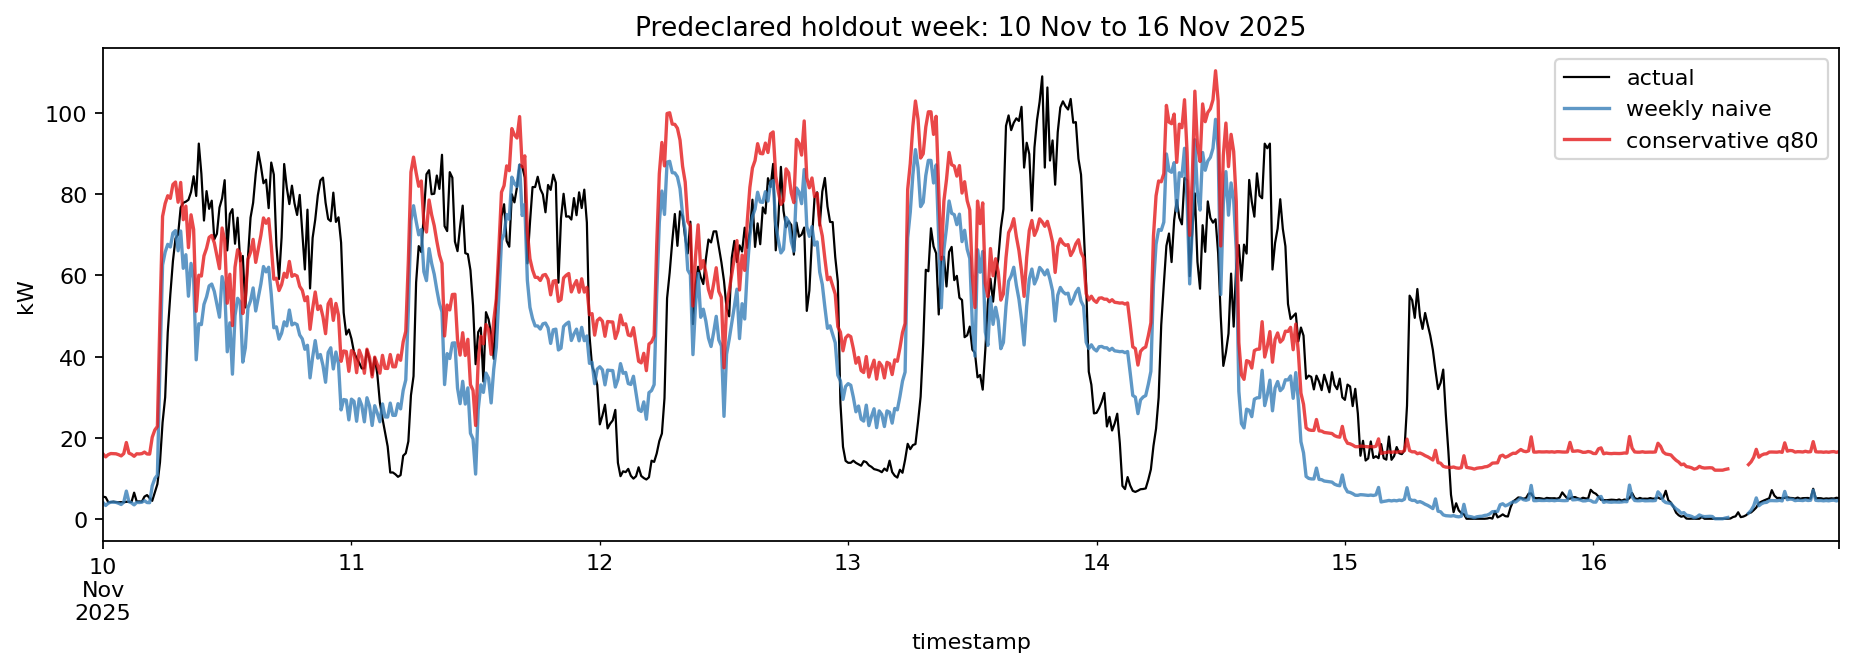

In [53]:
analysis = bess.run_forecast_analysis(frame, PLOT_DIR); metrics = analysis["metrics"]; actual = analysis["actual"]; conservative = analysis["forecast"]; print("Ridge challenger metrics:", analysis["ridge_metrics"]); display(analysis["rolling_metrics"]); display(metrics); display(*[Image(filename=str(path)) for path in analysis["plot_paths"]])

### Forecast results
The table reports the retained seasonal-naive and conservative baselines alongside the rolling-origin horizon results. The ridge challenger is available through `analysis["ridge_metrics"]` and uses only load-derived lags, rolling means, calendar variables, and German public-holiday flags. Promotion requires improvement in peak-aware metrics across rolling windows, not just one holdout.

In [48]:
frame = bess.add_german_holiday_flag(frame); print("German public-holiday intervals:", int(frame.is_public_holiday.sum()))

German public-holiday intervals: 864


### Calendar enrichment
Holiday flags are known before forecasting and can help distinguish normal weekday demand from shutdown or holiday behavior. They are available for a future production model but are not used to tune the reported baseline.

In [49]:
sim, threshold_scenarios = bess.run_dispatch_demo(frame, conservative); print("Peak before/after:", round(sim.load_kw.max(), 2), round(sim.net_load_kw.max(), 2)); display(threshold_scenarios)

Peak before/after: 109.1 109.1


,threshold_kw,risk_posture,peak_after_dispatch_kw,energy_discharged_kwh,illustrative_arbitrage_value_eur,rule
0,70,aggressive protection,109.1,92.00,9.200,Weekdays 08:00-18:00: clip forecast above 70 k...
1,80,balanced,109.1,92.00,9.200,Weekdays 08:00-18:00: clip forecast above 80 k...
2,90,arbitrage preserving,109.1,88.59,8.859,Weekdays 08:00-18:00: clip forecast above 90 k...


### Dispatch interpretation
This output converts the forecast into threshold rules and simulates discharge with explicit battery state of charge and power/energy limits. It reports peak load after dispatch, discharged energy, and an illustrative opportunity-cost estimate. The euro value is a scenario parameter, not a customer tariff result.

## Final recommendation

- **Default benchmark:** retain the weekly seasonal-naive model because it is transparent, stable, and easy to audit.
- **Peak-protection option:** use the conservative q80 forecast when avoiding missed demand peaks is more valuable than preserving battery capacity for arbitrage.
- **Candidate challenger:** retain the ridge model as a simple load-only challenger, but promote it only after it improves peak-aware metrics across rolling validation windows.
- **Control horizon:** refresh forecasts every 15 minutes and plan roughly 1-4 hours ahead; use the shorter horizon for immediate clipping and the longer horizon for SOC reservation.
- **Decision rule:** set the threshold from the customer tariff and battery constraints, not from forecast accuracy alone. The current EUR and battery values are illustrative assumptions.

The next production step is to validate these choices with client-specific demand-charge rules, process schedules, battery SOC history, and market-price data. Without that information, the model should be treated as a decision-support baseline rather than an automated dispatch policy.